# Función Alfa-Beta Zprim

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import sympy as sp

# Símbolos
r, b, alpha, mu = sp.symbols('r b alpha mu', real=True)

In [33]:
def E_tilde(b):
    return -7 + 288*b

def B_tilde(b):
    E = E_tilde(b)
    return 49 - 2268*b + 108*np.sqrt(21)*b*np.sqrt(E)

def D1_tilde(b):
    E = E_tilde(b)
    return 93312*b**2 + 7*np.sqrt(21)*np.sqrt(E) - 2268*b - 324*np.sqrt(21)*b*np.sqrt(E)

def D2_tilde(b):
    B = B_tilde(b)
    return -(7**(4/3)) + 216*(7**(1/3))*b + B**(2/3)


# ----- C̃(r) -----

def C_tilde(r, b, alpha, mu):

    E = E_tilde(b)
    B = B_tilde(b)
    D1 = D1_tilde(b)
    D2 = D2_tilde(b)

    term1 = -7*b*(-7 + 324*b)*r**4*alpha**3

    term2 = (972*(7**(2/3))*b**2*E*(B**(4/3))*alpha**3*mu)/(-D1*D2)

    inner = (
        -18*b*r**8
        + (7**(2/3)*(-7 + 324*b)*(B**(4/3))*r**4*mu)/(-D1*D2)
        - (486*(7**(1/3))*b*(-7 + 288*b)*(B**(8/3))*mu**2)/(D1**2 * D2**2)
    )

    term3 = 18*np.sqrt(42) * np.sqrt(
        -E * b**3 * alpha**6 * inner
    )

    prefactor = (373248/343) * b**2 * r**2 * alpha**3

    return prefactor * (term1 + term2 + term3)


# ----- función métrica f(r) -----

def fcompleta(r, b, alpha, mu):

    C = C_tilde(r, b, alpha, mu)

    return (
        1
        + r**2
        + (72*(7 - 216*b)*b*alpha**2*r**4)/(7**(4/3)*np.cbrt(C))
        + (7**(1/3)*np.cbrt(C))/(72*b*alpha**2)
    )

C:\Users\DanielManuelPechoVeg\AppData\Local\Temp\ipykernel_7388\2942471142.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("turbo")   # O "viridis", "plasma", "rainbow"
C:\Users\DanielManuelPechoVeg\AppData\Local\Temp\ipykernel_7388\3230833590.py:54: RuntimeWarning: divide by zero encountered in divide
  + (72*(7 - 216*b)*b*alpha**2*r**4)/(7**(4/3)*np.cbrt(C))
C:\Users\DanielManuelPechoVeg\AppData\Local\Temp\ipykernel_7388\3230833590.py:54: RuntimeWarning: invalid value encountered in divide
  + (72*(7 - 216*b)*b*alpha**2*r**4)/(7**(4/3)*np.cbrt(C))


0.03
<function fcompleta at 0x000001A7F6801D00>
0.03
<function fcompleta at 0x000001A7F6801D00>
0.03
<function fcompleta at 0x000001A7F6801D00>
0.03
<function fcompleta at 0x000001A7F6801D00>
0.03
<function fcompleta at 0x000001A7F6801D00>
0.03
<function fcompleta at 0x000001A7F6801D00>
0.03
<function fcompleta at 0x000001A7F6801D00>
0.03
<function fcompleta at 0x000001A7F6801D00>
0.1
<function fcompleta at 0x000001A7F6801D00>
0.1
<function fcompleta at 0x000001A7F6801D00>
0.1
<function fcompleta at 0x000001A7F6801D00>
0.1
<function fcompleta at 0x000001A7F6801D00>
0.1
<function fcompleta at 0x000001A7F6801D00>
0.1
<function fcompleta at 0x000001A7F6801D00>
0.1
<function fcompleta at 0x000001A7F6801D00>
0.1
<function fcompleta at 0x000001A7F6801D00>
0.5
<function fcompleta at 0x000001A7F6801D00>
0.5
<function fcompleta at 0x000001A7F6801D00>
0.5
<function fcompleta at 0x000001A7F6801D00>
0.5
<function fcompleta at 0x000001A7F6801D00>
0.5
<function fcompleta at 0x000001A7F6801D00>
0.5
<

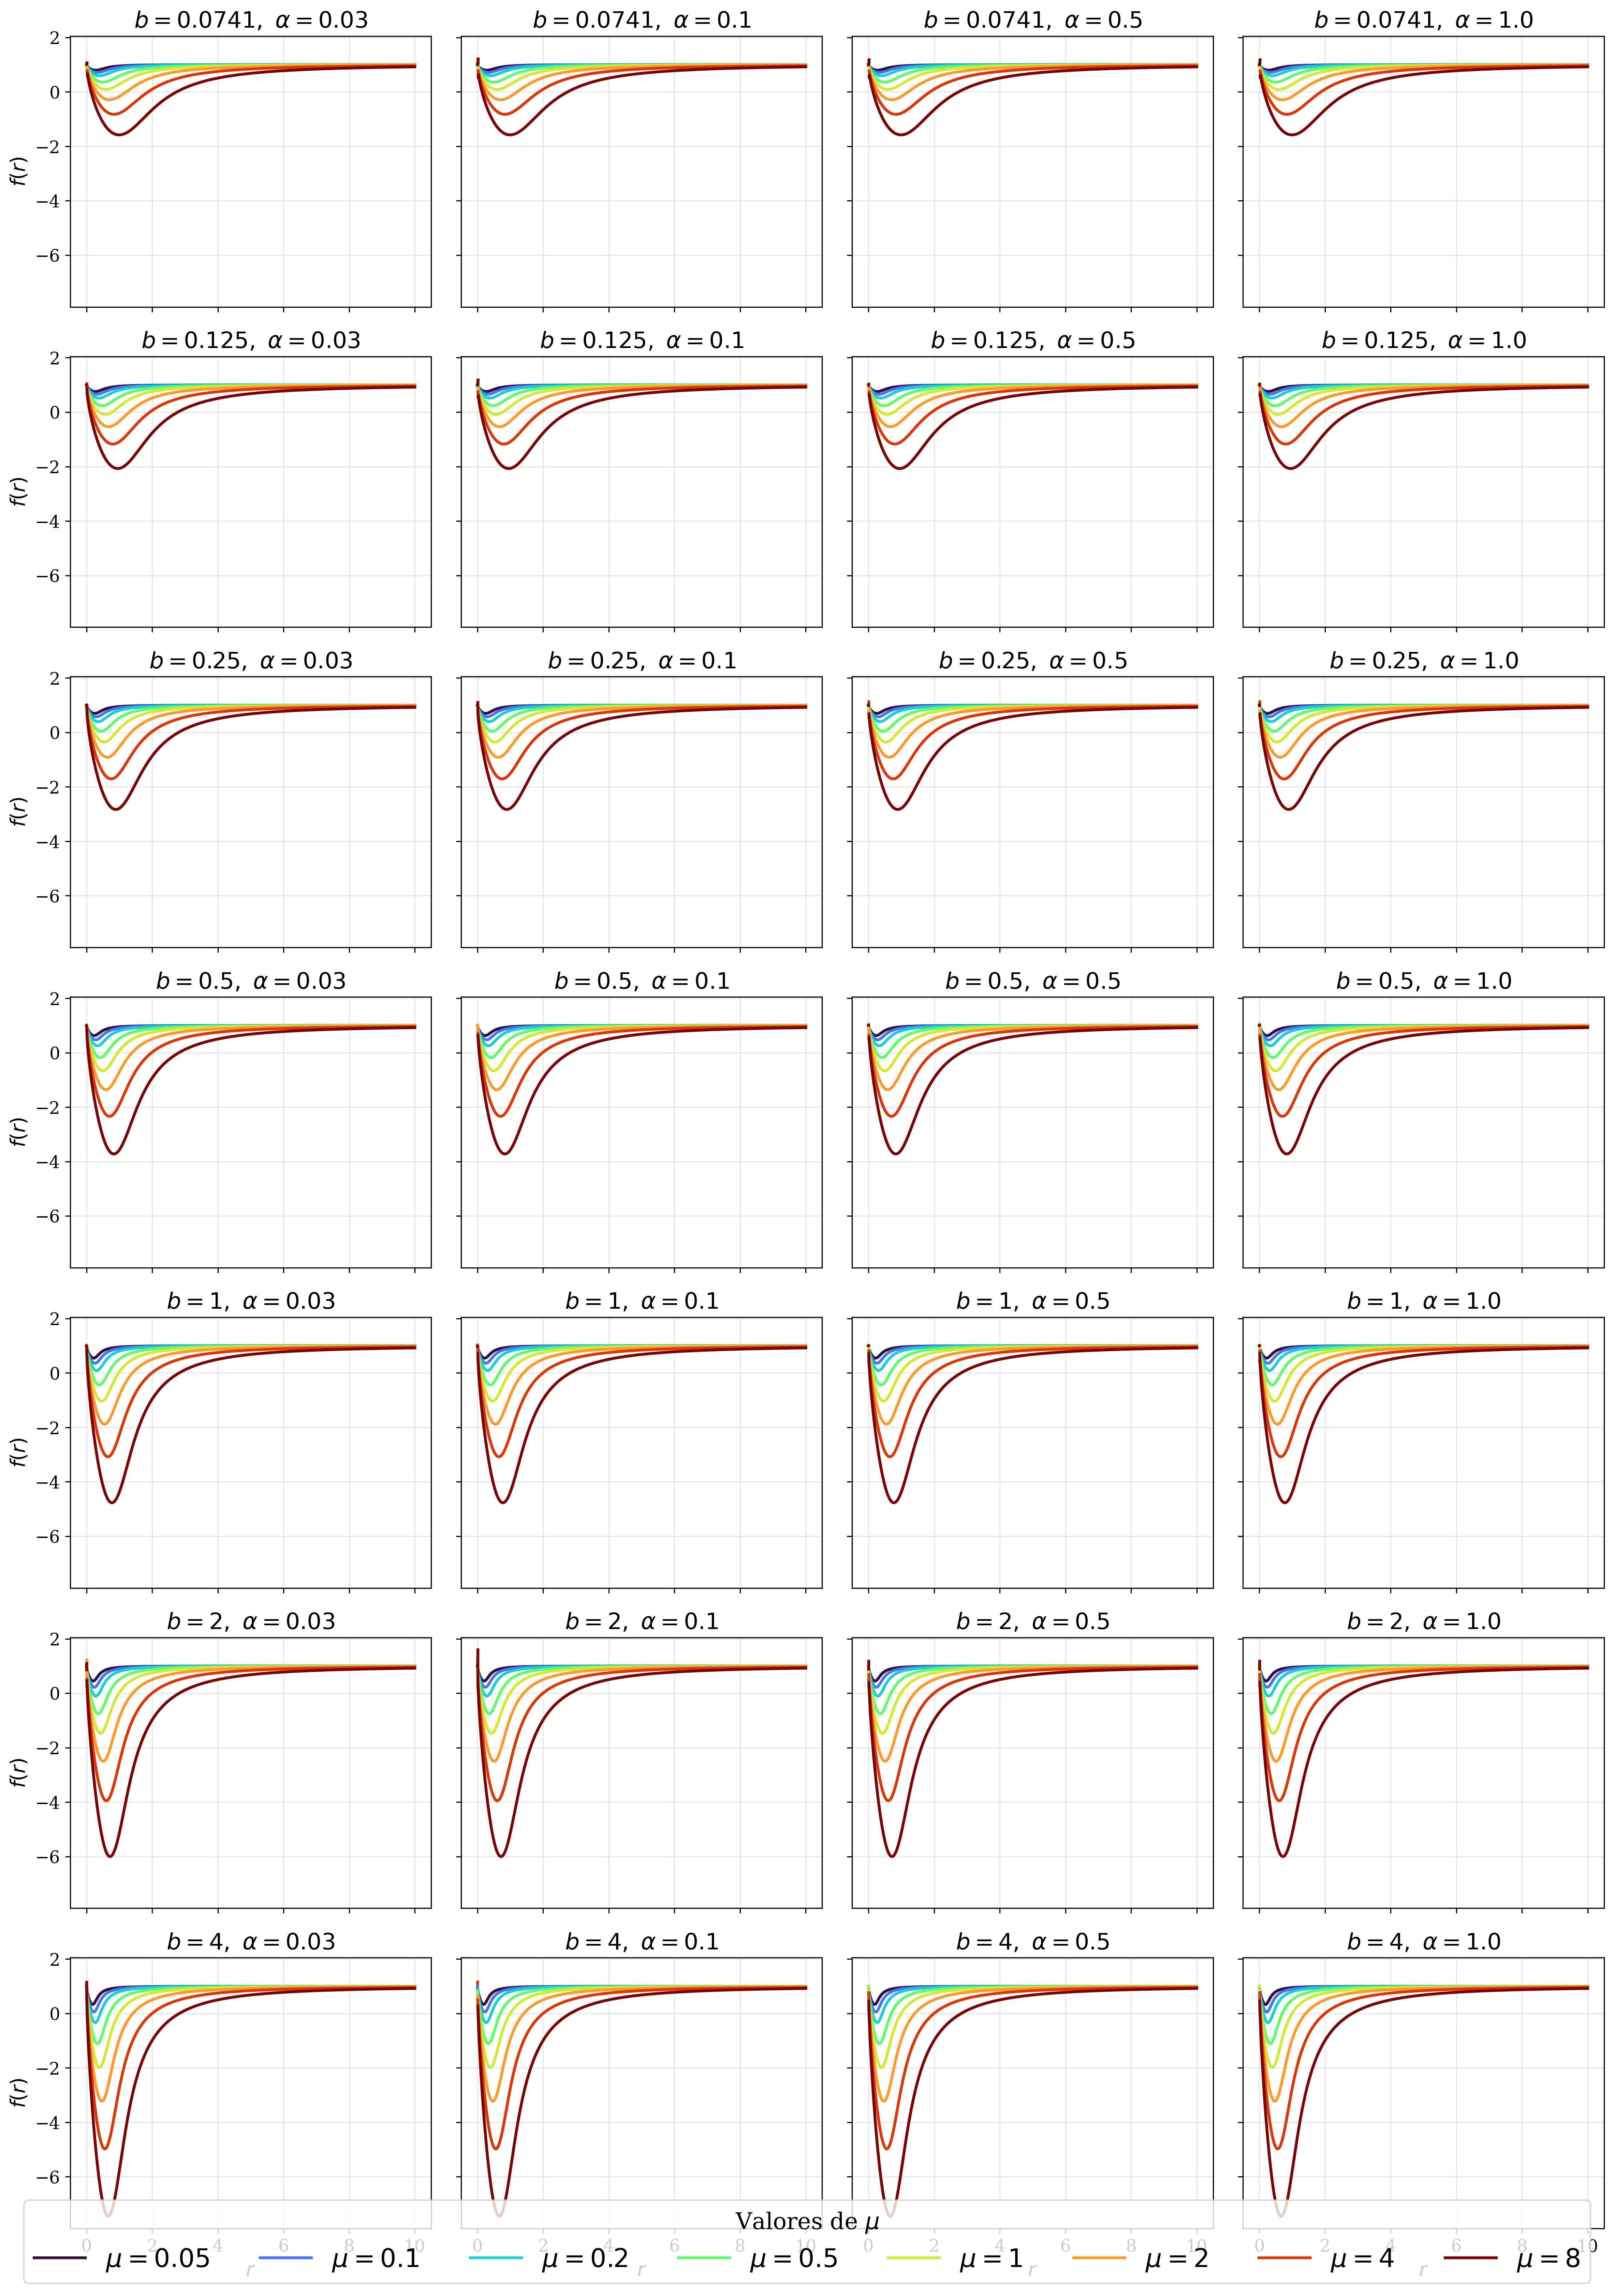

In [37]:
r_vals = np.linspace(0, 10, 10000)
mu_list = [0.05, 0.1, 0.2, 0.5, 1, 2, 4, 8]
b_list = [round(8/108,4), 1/8, 1/4,1/2,1,2,4]
alpha_list = [0.03,0.1, 0.5, 1.0]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "figure.dpi": 300,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 10,
    "lines.linewidth": 2
})

# Colormap profesional tipo arcoiris
cmap = get_cmap("turbo")   # O "viridis", "plasma", "rainbow"

# Crear grilla de subplots
fig, axes = plt.subplots(
    nrows=len(b_list),
    ncols=len(alpha_list),
    figsize=(4 * len(alpha_list), 3.5 * len(b_list)),
    sharex=True,
    sharey=True
)

# Asegurar que axes siempre sea 2D
axes = np.atleast_2d(axes)

for i, b in enumerate(b_list):
    for j, alpha in enumerate(alpha_list):
        ax = axes[i, j]
        
        for k, mu in enumerate(mu_list):
            color = cmap(k / (len(mu_list) - 1))
            ax.plot(
                r_vals,
                fcompleta(r_vals, b, alpha, mu),
                color=color
            )
            print(alpha)
            print(fcompleta)
        ax.set_title(fr"$b={b},\ \alpha={alpha}$")
        ax.grid(True, alpha=0.3)

        if i == len(b_list) - 1:
            ax.set_xlabel("$r$")
        if j == 0:
            ax.set_ylabel("$f(r)$")

# Leyenda común
handles = [
    plt.Line2D([0], [0], color=cmap(k/(len(mu_list)-1)), lw=2)
    for k in range(len(mu_list))
]
labels = [fr"$\mu={mu}$" for mu in mu_list]

fig.legend(
    handles, labels,
    title="Valores de $\mu$",
    loc="lower center",
    ncol=len(mu_list),
    frameon=True,
    fontsize=18,        # ← tamaño de la leyenda
    title_fontsize=16   # ← tamaño del título
)
plt.savefig("alfa-beta Zprim.png", dpi=300, bbox_inches="tight")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [41]:
print(fcompleta(1, 0.5, 0.03, 0.1))
print(fcompleta(1, 0.5, 1.0, 0.1))

0.9006607901234625
0.9006607901234651


SyntaxError: invalid syntax (204781646.py, line 1)